# **Linear Regression**


Linear Regression is a method to find a relationship between input variables (features) and an output variable (target).

***Importing Basic Libraries***

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**How can we load it in Python using pandas and see the first few rows?**.

In [143]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [144]:
df = pd.read_csv('/content/drive/MyDrive/MACHINE LEARNING/Linear_Regression/Dataset/Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Exploring the Data**

Check your dataset by some of the commands to quickly see its size, column names, missing values, and basic statistics.

In [145]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 9)


In [146]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [148]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [149]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [150]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


### Handling Null Values
Fill the missing values in the categorical columns by replacing them with the most frequent value in each column.

In [151]:
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [152]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [153]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [154]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


# 3. Exploratory Data Analysis

# **3.1 Distribution of Numerical Features**

# **Let's examine the distributions of the numerical variables to understand their range, spread, and potential outliers.**

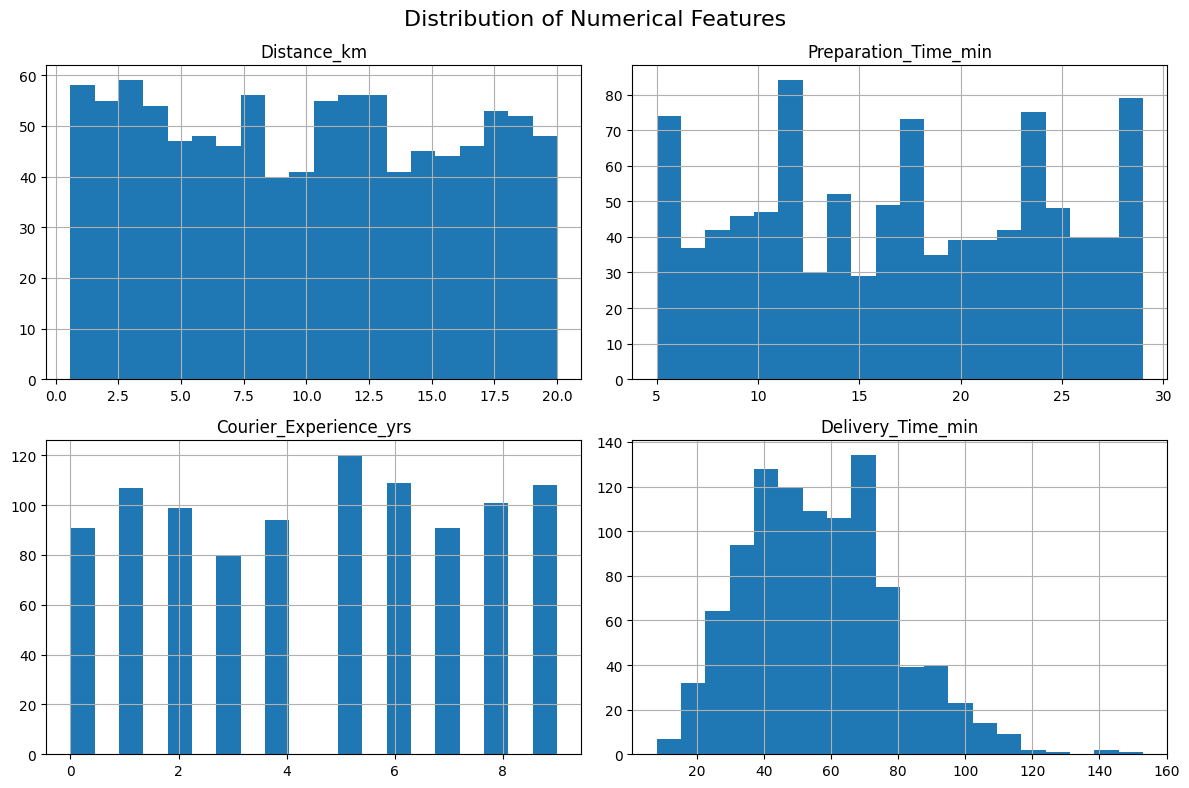

In [155]:
numeric_cols = [
    'Distance_km',
    'Preparation_Time_min',
    'Courier_Experience_yrs',
    'Delivery_Time_min'
]

df[numeric_cols].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### 3.2 Target Variable Distribution

The target variable is `Delivery_Time_min`. Understanding its distribution helps us determine whether the target contains skewness or extreme observations.

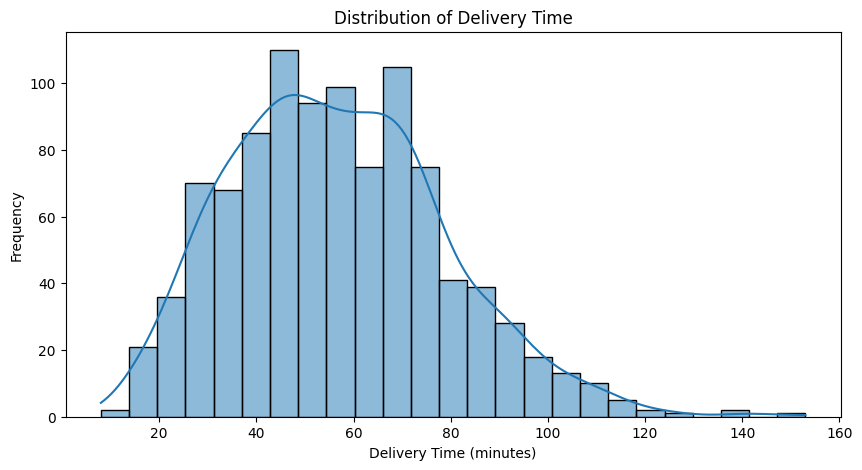

In [156]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Delivery_Time_min'],
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")

plt.show()

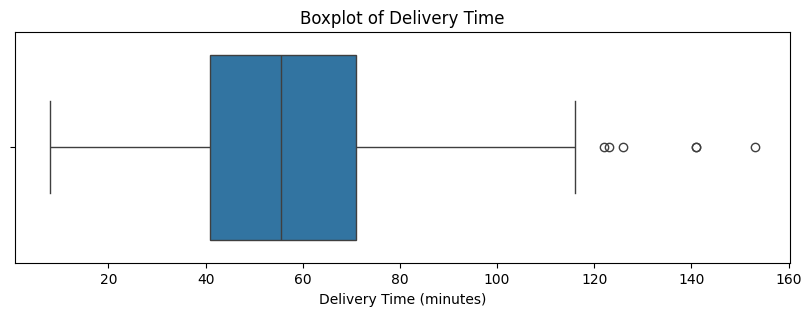

In [157]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df['Delivery_Time_min']
)

plt.title("Boxplot of Delivery Time")
plt.xlabel("Delivery Time (minutes)")

plt.show()

### 3.3 Numerical Features vs Delivery Time

Let's examine how numerical features relate to delivery time.

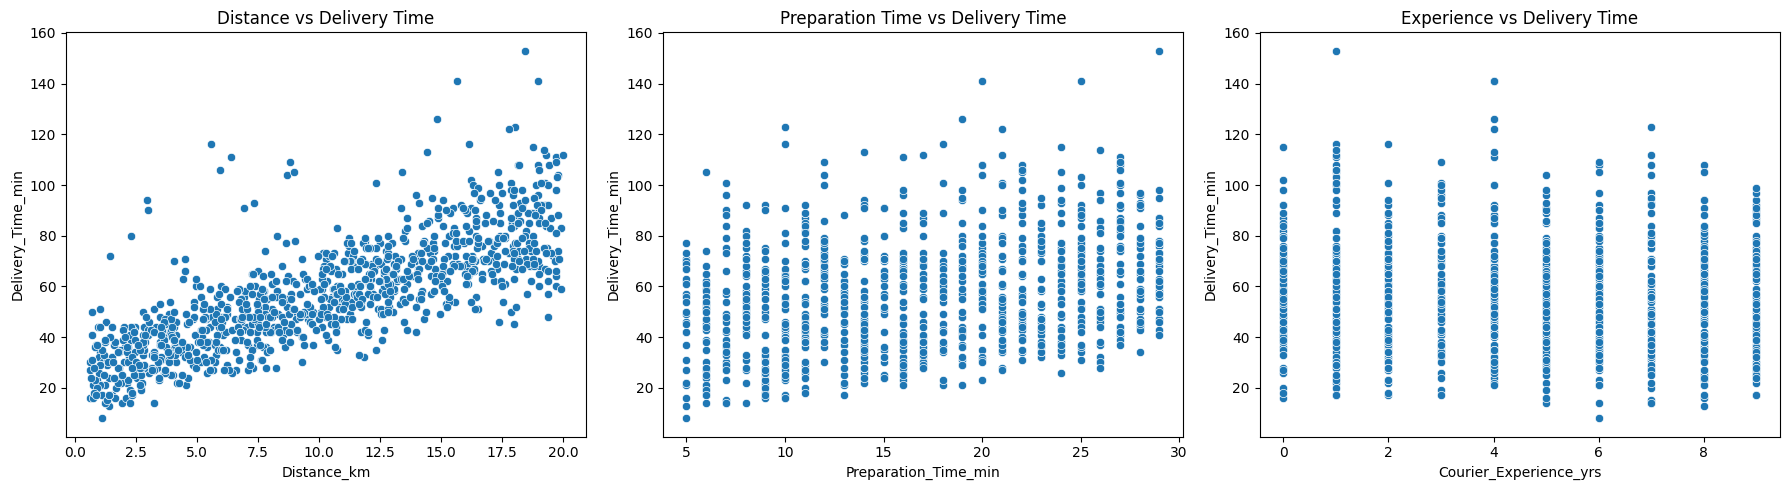

In [158]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df,
    x='Distance_km',
    y='Delivery_Time_min',
    ax=axes[0]
)

axes[0].set_title("Distance vs Delivery Time")

sns.scatterplot(
    data=df,
    x='Preparation_Time_min',
    y='Delivery_Time_min',
    ax=axes[1]
)

axes[1].set_title("Preparation Time vs Delivery Time")

sns.scatterplot(
    data=df,
    x='Courier_Experience_yrs',
    y='Delivery_Time_min',
    ax=axes[2]
)

axes[2].set_title("Experience vs Delivery Time")

plt.tight_layout()
plt.show()

### Observations

- Delivery time appears to increase as distance increases.
- Preparation time shows a positive relationship with delivery time.
- Courier experience appears to have a weaker relationship with delivery time compared with distance and preparation time.

### 3.4 Categorical Features vs Delivery Time

Let's compare delivery times across different categorical groups.

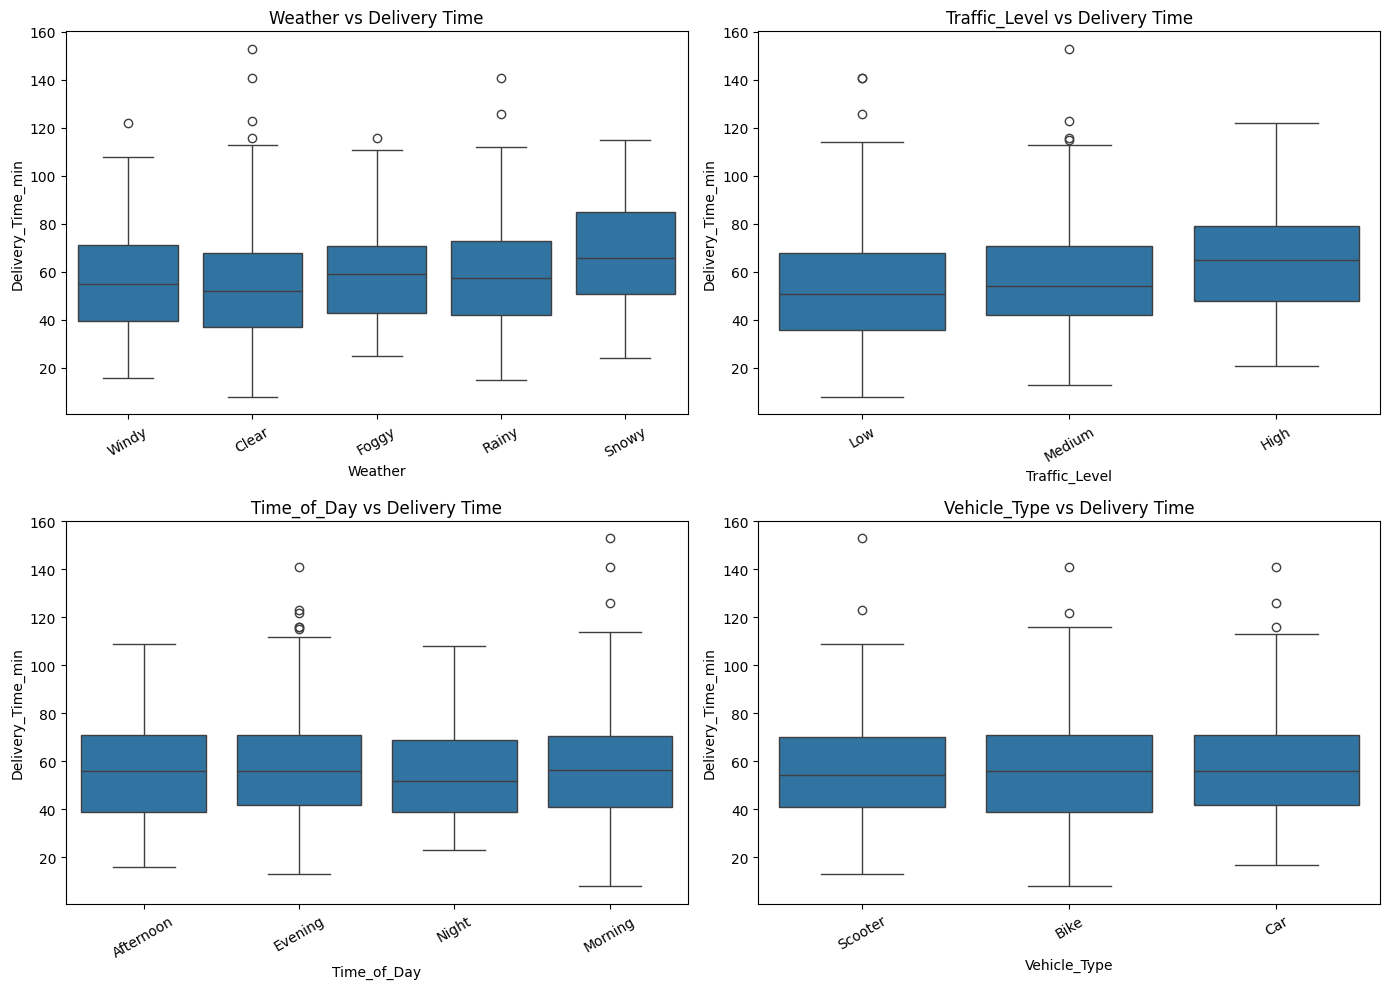

In [159]:
categorical_cols = [
    'Weather',
    'Traffic_Level',
    'Time_of_Day',
    'Vehicle_Type'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.boxplot(
        data=df,
        x=col,
        y='Delivery_Time_min',
        ax=ax
    )

    ax.set_title(f"{col} vs Delivery Time")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 3.5 Correlation Analysis

Correlation helps us understand the linear relationship between numerical variables.

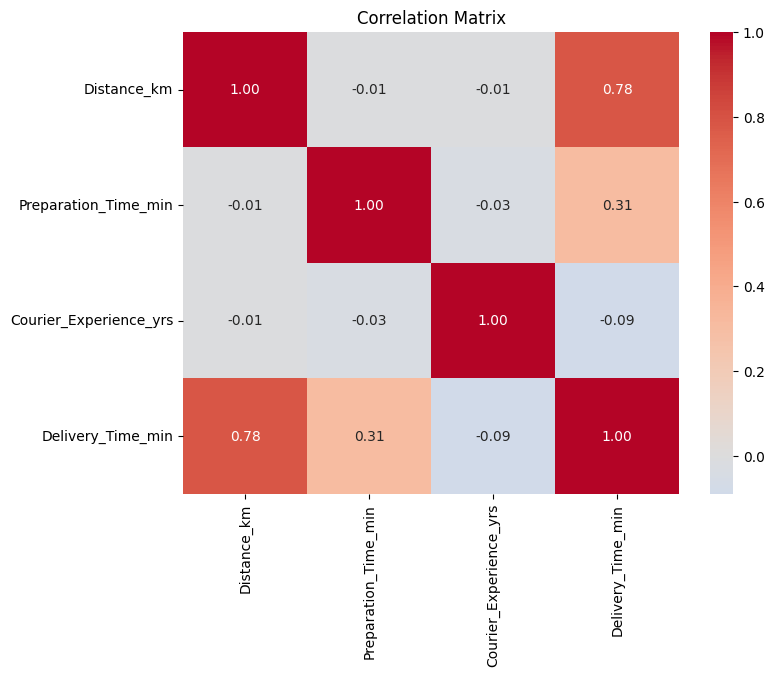

In [160]:
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [161]:
target_correlation = (
    df[numeric_cols]
    .corr()['Delivery_Time_min']
    .sort_values(ascending=False)
)

target_correlation

,Delivery_Time_min
Delivery_Time_min,1.000000
Distance_km,0.780998
Preparation_Time_min,0.307350
Courier_Experience_yrs,-0.089111


In [162]:
df_copy = df.copy()

In [163]:
df_dummies = pd.get_dummies(df_copy, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'])

In [164]:
df_dummies

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True
1,738,16.42,20,2.0,84,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False
2,741,9.52,28,1.0,59,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True
3,661,7.44,5,1.0,37,False,False,True,False,False,False,False,True,True,False,False,False,False,False,True
4,412,19.03,16,5.0,68,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,107,8.50,13,3.0,54,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False
996,271,16.28,8,9.0,71,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
997,861,15.62,26,2.0,81,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True
998,436,14.17,8,0.0,55,True,False,False,False,False,False,True,False,True,False,False,False,True,False,False


In [165]:
df_dummies.shape

(1000, 20)

In [166]:
df_dummies = df_dummies.astype(int)

In [167]:
df_dummies

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7,12,1,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,738,16,20,2,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,741,9,28,1,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,661,7,5,1,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,412,19,16,5,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,107,8,13,3,54,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0
996,271,16,8,9,71,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
997,861,15,26,2,81,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
998,436,14,8,0,55,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0


## **Defining Features and Target**

X (features) → known factors (distance, traffic, weather, etc.)

y (target) → what we want to predict (delivery time)


In [168]:
X_dummies = df_dummies.drop(['Delivery_Time_min', 'Order_ID'], axis=1)
y_dummies = df_dummies['Delivery_Time_min']

## Splitting Data into Train and Test Sets**

How can we check how well our model performs on unseen data?
Why do we split the dataset into two parts:

Training set (80%) → used to train the model

Testing set (20%) → used to evaluate the model.

## Training the Linear Regression Model**

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_dummies, y_dummies, test_size=0.2, random_state=42)

In [170]:
from sklearn.linear_model import LinearRegression

In [174]:
model_dummies = LinearRegression()
model_dummies.fit(X_train, y_train)

LinearRegression()

## Making Predictions

Use the trained model to predict delivery times for the test data.

In [171]:
y_predict = model_dummies.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

adj_r2 = 1 - ((1 - r2) * (df_dummies.shape[0]-1)) / (df_dummies.shape[0] - df_dummies.shape[1] - 1)

In [172]:
r2

0.8195989431508369

In [173]:
adj_r2

0.8159135283020287

# Conclusion
-Predicted food delivery times using features like distance, traffic, weather, time, and courier experience.

-Applied Linear Regression for basic predictions.

-Used Ridge and Lasso to reduce overfitting and improve accuracy.

-Explored Polynomial Regression to capture nonlinear relationships.

-Evaluated models with MAE, MSE, and R² to measure performance.

-Demonstrated a real-world application of regression in optimizing delivery operations.